In [34]:
# Importy i ustawienia
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
np.random.seed(42)
torch.manual_seed(42)
print("Importy załadowane, seed ustawiony.")
cuda = torch.cuda.is_available()
print("CUDA dostępne:", cuda)

Importy załadowane, seed ustawiony.
CUDA dostępne: True


In [ ]:

# Komórka 2: Implementacja LSTM i Attention w numpy
class LSTM:
    def __init__(self, input_size, hidden_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.Wf = np.random.randn(hidden_size, input_size + hidden_size) * 0.01
        self.bf = np.zeros((hidden_size, 1))
        self.Wi = np.random.randn(hidden_size, input_size + hidden_size) * 0.01
        self.bi = np.zeros((hidden_size, 1))
        self.Wc = np.random.randn(hidden_size, input_size + hidden_size) * 0.01
        self.bc = np.zeros((hidden_size, 1))
        self.Wo = np.random.randn(hidden_size, input_size + hidden_size) * 0.01
        self.bo = np.zeros((hidden_size, 1))
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    def tanh(self, x):
        return np.tanh(x)
    def forward(self, x, h_prev, c_prev):
        concat = np.vstack((h_prev, x))
        ft = self.sigmoid(np.dot(self.Wf, concat) + self.bf)
        it = self.sigmoid(np.dot(self.Wi, concat) + self.bi)
        c_tilde = self.tanh(np.dot(self.Wc, concat) + self.bc)
        ct = ft * c_prev + it * c_tilde
        ot = self.sigmoid(np.dot(self.Wo, concat) + self.bo)
        ht = ot * self.tanh(ct)
        return ht, ct
    def forward_sequence(self, x_seq, h0=None, c0=None):
        seq_len = x_seq.shape[0]
        h = np.zeros((self.hidden_size, 1)) if h0 is None else h0
        c = np.zeros((self.hidden_size, 1)) if c0 is None else c0
        outputs = []
        for t in range(seq_len):
            x_t = x_seq[t].reshape(-1, 1)
            h, c = self.forward(x_t, h, c)
            outputs.append(h)
        outputs = np.concatenate(outputs, axis=1)
        return outputs, h, c

class LSTMWithAttention(LSTM):
    def __init__(self, input_size, hidden_size):
        super().__init__(input_size, hidden_size)
        self.W_a = np.random.randn(1, hidden_size) * 0.01
        self.b_a = np.zeros((1, 1))
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    def forward_with_attention(self, x_seq, h0=None, c0=None):
        outputs, h_final, c_final = self.forward_sequence(x_seq, h0, c0)
        scores = np.tanh(np.dot(self.W_a, outputs) + self.b_a)
        att_weights = self.softmax(scores)
        context_vector = np.sum(outputs * att_weights, axis=1, keepdims=True)
        return context_vector, att_weights, h_final, c_final

print("LSTM i LSTMWithAttention zaimplementowane.")

LSTM i LSTMWithAttention zaimplementowane.


In [36]:
# Komórka 3: Funkcje do tokenizacji i BPE
def convert_text_to_bytes(text):
    return list(map(int, text.encode('utf-8')))
def merge_pair_single(token_list, pair_to_merge, new_token):
    new_list, i = [], 0
    while i < len(token_list):
        if i < len(token_list) - 1 and (token_list[i], token_list[i+1]) == pair_to_merge:
            new_list.append(new_token); i += 2
        else:
            new_list.append(token_list[i]); i += 1
    return new_list
def iterative_merge(token_list, num_iterations, start_token=256):
    new_token = start_token
    current_tokens = token_list
    for _ in range(num_iterations):
        stats = {}
        for pair in zip(current_tokens, current_tokens[1:]):
            stats[pair] = stats.get(pair, 0) + 1
        if not stats: break
        most_common_pair = max(stats, key=stats.get)
        current_tokens = merge_pair_single(current_tokens, most_common_pair, new_token)
        new_token += 1
    return current_tokens

print("Funkcje tokenizacji i BPE gotowe.")


Funkcje tokenizacji i BPE gotowe.


In [37]:
# Komórka 4: Implementacja Generatora i Dyskryminatora (PyTorch)
class LSTMGeneratorPyTorch(nn.Module):
    def __init__(self, latent_dim, hidden_dim, embedding_dim, seq_len):
        super().__init__()
        self.seq_len = seq_len
        self.hidden_dim = hidden_dim
        self.fc = nn.Linear(latent_dim, hidden_dim * seq_len)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=1, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, embedding_dim)
    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, self.seq_len, self.hidden_dim)
        lstm_out, _ = self.lstm(x)
        output = self.output_layer(lstm_out)
        return output

class DiscriminatorPyTorch(nn.Module):
    def __init__(self, embedding_dim, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=1, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        features = torch.mean(lstm_out, dim=1)
        output = self.fc(features)
        return torch.sigmoid(output)

print("Generator i Dyskryminator gotowe.")

Generator i Dyskryminator gotowe.


In [38]:
# Komórka: 5 wczytanie danych

# 1. Wczytanie danych
df = pd.read_csv('fake_or_real_news.csv')[['title', 'text', 'label']]
print("Wczytano dane:", df.shape)

# 2. Podział na REAL i FAKE
df_real_all = df[df['label'] == 'REAL'].copy().reset_index(drop=True)
df_fake_all = df[df['label'] == 'FAKE'].copy().reset_index(drop=True)

# 3. Dodajemy kolumnę 'signature' = title + text, aby wyłapać duplikaty
df_real_all['signature'] = df_real_all['title'].str.strip() + "__SEP__" + df_real_all['text'].str.strip()
df_fake_all['signature'] = df_fake_all['title'].str.strip() + "__SEP__" + df_fake_all['text'].str.strip()

# 4. Dla REAL: bierzemy unikalne sygnatury i dzielimy je na train/test
unique_real_sigs = df_real_all['signature'].unique()
# losowo wybieramy połowę unikalnych sygnatur do train
train_sigs = pd.Series(unique_real_sigs).sample(frac=0.5, random_state=42).tolist()
# pozostałe sygnatury trafią do testu
test_sigs  = [sig for sig in unique_real_sigs if sig not in train_sigs]

# 5. Budujemy df_real_train i df_real_test tak, żeby cały klastrowy sygnat trafiał wyłącznie do jednego zestawu:
df_real_train = df_real_all[df_real_all['signature'].isin(train_sigs)].reset_index(drop=True)
df_real_test  = df_real_all[df_real_all['signature'].isin(test_sigs)].reset_index(drop=True)

# 6. Dla FAKE: w teście chcemy dokładnie tyle samo FAKE co REAL w df_real_test
n_real_test = len(df_real_test['signature'].unique())
# wybieramy z całego zestawu FAKE tyle unikalnych sygnatur, ile mamy REAL-ów w teście
unique_fake_sigs = df_fake_all['signature'].unique()
fake_test_sigs = pd.Series(unique_fake_sigs).sample(n=n_real_test, random_state=42).tolist()
df_fake_test = df_fake_all[df_fake_all['signature'].isin(fake_test_sigs)].reset_index(drop=True)

# 7. Teraz składamy df_train i df_test:
#   - df_train: tylko REAL (bez etykiet, bez kolumny 'signature')
#   - df_test: zarówno REAL, jak i FAKE, z kolumną 'true_label' i bez 'signature'
df_train = df_real_train[['title', 'text']].copy()

df_real_test  = df_real_test[['title', 'text']].copy().assign(true_label=0)
df_fake_test  = df_fake_test[['title', 'text']].copy().assign(true_label=1)

df_test = pd.concat([df_real_test, df_fake_test], ignore_index=True)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)  # przemieszaj

# 8. Podsumowanie liczb
print(f"Zbiór treningowy (REAL): {len(df_train)} wierszy")
print(f"Zbiór testowy: {len(df_test)} wierszy (REAL + FAKE)")
print(f"  -> REAL w teście: {len(df_real_test)}")
print(f"  -> FAKE w teście: {len(df_fake_test)}")


Wczytano dane: (6335, 3)
Zbiór treningowy (REAL): 1586 wierszy
Zbiór testowy: 3168 wierszy (REAL + FAKE)
  -> REAL w teście: 1585
  -> FAKE w teście: 1583


In [39]:
# Komórka: 6 BPE 
from collections import Counter, defaultdict

# 1. Konwersja wszystkich tytułów i tekstów z df_train do list bajtów
all_sequences = []
for col in ['title', 'text']:
    for txt in df_train[col]:
        bs = list(txt.encode('utf-8'))
        all_sequences.append(bs)

# 2. Zliczanie częstotliwości par bajtów w całym df_train
pair_counts = Counter()
for seq in all_sequences:
    for i in range(len(seq)-1):
        pair = (seq[i], seq[i+1])
        pair_counts[pair] += 1

# 3. Wybierz kolejno opt_steps najczęstszych par, aktualizując pary po każdej iteracji
bpe_merges = []  # tu będziemy trzymać krotki (a,b) do łączenia w kolejności
opt_steps = 5

for _ in range(opt_steps):
    if not pair_counts:
        break
    # wybierz najbardziej popularną parę
    best_pair, _ = pair_counts.most_common(1)[0]
    bpe_merges.append(best_pair)

    # Teraz musimy „zaktualizować” pary w całym korpusie: 
    # każdorazowo łączymy best_pair w każdej sekwencji i przeliczamy pary,
    # ale w praktyce przy dużych danych robi się to sprytniej (np. trzymając słowniki pozycji),
    # tutaj jednak dla czytelności po prostu przeliczamy na nowo:

    # zresetuj liczniki i ponownie zliczaj kolejki w zaktualizowanych sekwencjach
    new_pair_counts = Counter()
    updated_sequences = []
    for seq in all_sequences:
        # łączenie best_pair w jednej sekwencji
        merged_seq = []
        i = 0
        while i < len(seq):
            if i < len(seq)-1 and (seq[i], seq[i+1]) == best_pair:
                # zamieniamy dwa bajty na jeden „symbol” (np. tuple)
                merged_elem = (seq[i], seq[i+1])
                merged_seq.append(merged_elem)
                i += 2
            else:
                merged_seq.append(seq[i])
                i += 1
        updated_sequences.append(merged_seq)

    # Teraz zaktualizujemy pair_counts na podstawie updated_sequences
    for seq in updated_sequences:
        for i in range(len(seq)-1):
            pair = (seq[i], seq[i+1])
            new_pair_counts[pair] += 1

    # Podstawiamy new_pair_counts jako nasz aktualny licznik
    pair_counts = new_pair_counts
    # i podmieniamy sekwencje
    all_sequences = updated_sequences

# bpe_merges teraz zawiera listę opt_steps najbardziej popularnych (a,b)
print("Wybrane merge'y BPE:", bpe_merges)


Wybrane merge'y BPE: [(101, 32), (32, 116), (115, 32), (105, 110), ((32, 116), 104)]


In [40]:
def apply_bpe(tokens, merges):
    """
    tokens: list bajtów lub tuple-ów (już po wcześniejszych łączeniach)
    merges: lista krotek, które wybraliśmy w fazie uczenia
    """
    seq = tokens[:]  # skopiuj listę
    for merge_pair in merges:
        merged_seq = []
        i = 0
        while i < len(seq):
            # jeśli uda się dopasować parę merge_pair
            if i < len(seq)-1 and seq[i] == merge_pair[0] and seq[i+1] == merge_pair[1]:
                merged_seq.append(merge_pair)  # traktujemy połączone jako tupla
                i += 2
            else:
                merged_seq.append(seq[i])
                i += 1
        seq = merged_seq
    return seq


In [41]:
# 1) Najpierw nauka merge'ów BPE na df_train
all_sequences = []
for col in ['title', 'text']:
    for txt in df_train[col]:
        bs = list(txt.encode('utf-8'))
        all_sequences.append(bs)

from collections import Counter
pair_counts = Counter()
for seq in all_sequences:
    for i in range(len(seq)-1):
        pair_counts[(seq[i], seq[i+1])] += 1

bpe_merges = []
opt_steps = 5
for _ in range(opt_steps):
    if not pair_counts:
        break
    best_pair, _ = pair_counts.most_common(1)[0]
    bpe_merges.append(best_pair)

    # aktualizacja sekwencji i par (jak w sekcji A)
    new_pair_counts = Counter()
    updated_sequences = []
    for seq in all_sequences:
        merged_seq = []
        i = 0
        while i < len(seq):
            if i < len(seq)-1 and (seq[i], seq[i+1]) == best_pair:
                merged_seq.append((seq[i], seq[i+1]))
                i += 2
            else:
                merged_seq.append(seq[i])
                i += 1
        updated_sequences.append(merged_seq)
    # przelicz pary
    for seq in updated_sequences:
        for i in range(len(seq)-1):
            new_pair_counts[(seq[i], seq[i+1])] += 1
    pair_counts = new_pair_counts
    all_sequences = updated_sequences

print("Nauczone merge'y BPE:", bpe_merges)


# 2) Teraz APLIKUJEMY BPE na df_train i df_test:
def convert_text_to_bytes(text):
    return list(text.encode('utf-8'))

# a) dla df_train: utworzymy kolumny title_bytes / text_bytes
df_train['title_bytes'] = df_train['title'].apply(convert_text_to_bytes)
df_train['text_bytes'] = df_train['text'].apply(convert_text_to_bytes)

df_train['title_bpe'] = df_train['title_bytes'].apply(lambda t: apply_bpe(t, bpe_merges))
df_train['text_bpe'] = df_train['text_bytes'].apply(lambda t: apply_bpe(t, bpe_merges))


# b) dla df_test: analogicznie (ważne, by NIE przeliczać nowych merge'ów)
df_test['title_bytes'] = df_test['title'].apply(convert_text_to_bytes)
df_test['text_bytes'] = df_test['text'].apply(convert_text_to_bytes)

df_test['title_bpe'] = df_test['title_bytes'].apply(lambda t: apply_bpe(t, bpe_merges))
df_test['text_bpe'] = df_test['text_bytes'].apply(lambda t: apply_bpe(t, bpe_merges))


print("Tokenizacja i BPE na df_train i df_test zakończone.")


Nauczone merge'y BPE: [(101, 32), (32, 116), (115, 32), (105, 110), ((32, 116), 104)]
Tokenizacja i BPE na df_train i df_test zakończone.


In [ ]:

# 1. Zbuduj słownik token → indeks na podstawie zarówno df_train, jak i df_test
all_tokens = set()
for df_ in [df_train, df_test]:
    for col in ['title_bpe', 'text_bpe']:
        for seq in df_[col]:
            for tok in seq:
                all_tokens.add(tok)

# Przydziel każdemu unikalnemu tokenowi unikalny indeks (bez <unk>)
token2idx = {tok: idx for idx, tok in enumerate(all_tokens)}
num_embeddings = len(token2idx)
print(f"Liczba unikalnych tokenów w słowniku: {num_embeddings}")

# 2. Funkcja konwertująca sekwencję tokenów na sekwencję indeksów
def tokens_to_indices(seq):
    return [token2idx[tok] for tok in seq]

# Zamień w df_train:
df_train['title_idx'] = df_train['title_bpe'].apply(tokens_to_indices)
df_train['text_idx']  = df_train['text_bpe'].apply(tokens_to_indices)

# Zamień w df_test:
df_test['title_idx'] = df_test['title_bpe'].apply(tokens_to_indices)
df_test['text_idx']  = df_test['text_bpe'].apply(tokens_to_indices)

# 3. Utwórz warstwę nn.Embedding
embedding_dim = 50  # przykładowa wymiarowość
embedding_layer = nn.Embedding(num_embeddings=num_embeddings, embedding_dim=embedding_dim)

# 4. Funkcja zwracająca embedding sekwencji (zwraca tensor [seq_len, embedding_dim])
def embed_sequence(idx_list):
    idx_tensor = torch.tensor(idx_list, dtype=torch.long)
    with torch.no_grad():
        return embedding_layer(idx_tensor)  # [seq_len, embedding_dim]

# 5. Generowanie embeddingów jako NumPy arrays
df_train['title_emb'] = df_train['title_idx'].apply(lambda idxs: embed_sequence(idxs).cpu().numpy())
df_train['text_emb']  = df_train['text_idx'].apply(lambda idxs: embed_sequence(idxs).cpu().numpy())

df_test['title_emb'] = df_test['title_idx'].apply(lambda idxs: embed_sequence(idxs).cpu().numpy())
df_test['text_emb']  = df_test['text_idx'].apply(lambda idxs: embed_sequence(idxs).cpu().numpy())

print("Embeddingi gotowe w df_train i df_test.")


Liczba unikalnych tokenów w słowniku: 184
Embeddingi gotowe w df_train i df_test.


,title,text,title_bytes,text_bytes,title_bpe,text_bpe,title_idx,text_idx,title_emb,text_emb
0,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,"[75, 101, 114, 114, 121, 32, 116, 111, 32, 103...","[85, 46, 83, 46, 32, 83, 101, 99, 114, 101, 11...","[75, 101, 114, 114, 121, (32, 116), 111, 32, 1...","[85, 46, 83, 46, 32, 83, 101, 99, 114, 101, 11...","[45, 71, 84, 84, 91, 181, 81, 2, 73, 81, 181, ...","[55, 16, 53, 16, 2, 53, 71, 69, 84, 71, 86, 67...","[[-0.78318167, -0.92557424, 0.19684368, 0.3033...","[[-1.0486304, -1.5234541, 0.9250113, -0.300371..."
1,"Trump takes on Cruz, but lightly","Killing Obama administration rules, dismantlin...","[84, 114, 117, 109, 112, 32, 116, 97, 107, 101...","[75, 105, 108, 108, 105, 110, 103, 32, 79, 98,...","[84, 114, 117, 109, 112, (32, 116), 97, 107, 1...","[75, 105, 108, 108, (105, 110), 103, 32, 79, 9...","[54, 84, 87, 79, 82, 181, 67, 77, 71, 0, 81, 8...","[45, 75, 78, 78, 180, 73, 2, 49, 68, 67, 79, 6...","[[-0.28997287, -0.61414593, -1.3034389, 0.4951...","[[-0.78318167, -0.92557424, 0.19684368, 0.3033..."
2,How women lead differently,"As more women move into high offices, they oft...","[72, 111, 119, 32, 119, 111, 109, 101, 110, 32...","[65, 115, 32, 109, 111, 114, 101, 32, 119, 111...","[72, 111, 119, 32, 119, 111, 109, 101, 110, 32...","[65, (115, 32), 109, 111, 114, (101, 32), 119,...","[42, 81, 89, 2, 89, 81, 79, 71, 80, 2, 78, 71,...","[35, 0, 79, 81, 84, 143, 89, 81, 79, 71, 80, 2...","[[-0.43161988, -1.3593959, 0.08212801, -0.3389...","[[0.9646967, 1.578055, 1.207335, 0.61063755, -..."
3,Hillary Clinton Makes A Bipartisan Appeal on S...,Hillary Clinton told a Staten Island crowd tod...,"[72, 105, 108, 108, 97, 114, 121, 32, 67, 108,...","[72, 105, 108, 108, 97, 114, 121, 32, 67, 108,...","[72, 105, 108, 108, 97, 114, 121, 32, 67, 108,...","[72, 105, 108, 108, 97, 114, 121, 32, 67, 108,...","[42, 75, 78, 78, 67, 84, 91, 2, 37, 78, 180, 8...","[42, 75, 78, 78, 67, 84, 91, 2, 37, 78, 180, 8...","[[-0.43161988, -1.3593959, 0.08212801, -0.3389...","[[-0.43161988, -1.3593959, 0.08212801, -0.3389..."
4,New Senate majority leader’s main goal for GOP...,Mitch McConnell has an unusual admonition for ...,"[78, 101, 119, 32, 83, 101, 110, 97, 116, 101,...","[77, 105, 116, 99, 104, 32, 77, 99, 67, 111, 1...","[78, 101, 119, 32, 83, 101, 110, 97, 116, (101...","[77, 105, 116, 99, 104, 32, 77, 99, 67, 111, 1...","[48, 71, 89, 2, 53, 71, 80, 67, 86, 143, 79, 6...","[47, 75, 86, 69, 74, 2, 47, 69, 37, 81, 80, 80...","[[0.8454862, -0.16637278, -0.9805456, -0.50566...","[[0.6599026, -1.0502111, 1.086033, 0.30472198,..."
...,...,...,...,...,...,...,...,...,...,...
1581,Why Ted Cruz Has the Most to Lose in New Hamps...,Ted Cruz took first prize in the Iowa caucuses...,"[87, 104, 121, 32, 84, 101, 100, 32, 67, 114, ...","[84, 101, 100, 32, 67, 114, 117, 122, 32, 116,...","[87, 104, 121, 32, 84, 101, 100, 32, 67, 114, ...","[84, 101, 100, 32, 67, 114, 117, 122, (32, 116...","[57, 74, 91, 2, 54, 71, 70, 2, 37, 84, 87, 92,...","[54, 71, 70, 2, 37, 84, 87, 92, 181, 81, 81, 7...","[[0.60920775, -0.0335992, -2.3475199, 1.263369...","[[-0.28997287, -0.61414593, -1.3034389, 0.4951..."
1582,Bernie Sanders says private meeting with Pope ...,ROME — U.S. Democratic presidential candidate...,"[66, 101, 114, 110, 105, 101, 32, 83, 97, 110,...","[82, 79, 77, 69, 32, 226, 128, 148, 194, 160, ...","[66, 101, 114, 110, 105, (101, 32), 83, 97, 11...","[82, 79, 77, 69, 32, 226, 128, 148, 194, 160, ...","[36, 71, 84, 80, 75, 143, 53, 67, 80, 70, 71, ...","[52, 49, 47, 39, 2, 177, 98, 118, 162, 130, 16...","[[-0.81096756, -1.8637484, 0.7676362, -0.54304...","[[-0.59523255, 1.2561524, -0.0909453, 0.476048..."
1583,GOP Senator David Perdue Jokes About Praying f...,The freshman senator from Georgia quoted scrip...,"[71, 79, 80, 32, 83, 101, 110, 97, 116, 111, 1...","[84, 104, 101, 32, 102, 114, 101, 115, 104, 10...","[71, 79, 80, 32, 83, 101, 110, 97, 116, 111, 1...","[84, 104, (

In [47]:
# Komórka 8: LSTM z attention na embeddingach

class LSTMWithAttention(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMWithAttention, self).__init__()
        self.hidden_size = hidden_size
        # jednokierunkowy LSTM
        self.lstm = nn.LSTM(input_size=input_size, 
                            hidden_size=hidden_size, 
                            batch_first=True)
        # warstwa do liczenia score'ów uwagi
        self.attn_fc = nn.Linear(hidden_size, hidden_size)
        self.attn_tanh = nn.Tanh()
        self.attn_score = nn.Linear(hidden_size, 1, bias=False)

    def forward_with_attention(self, seq_np):
        """
        seq_np: numpy array o kształcie [seq_len, input_size]
        Zwraca: 
          context_vector: tensor [1, hidden_size]
          attn_weights: tensor [1, seq_len]
          h_final: tensor [1, hidden_size]
          c_final: tensor [1, hidden_size]
        """
        # Konwersja sekwencji na tensor: [1, seq_len, input_size]
        seq = torch.tensor(seq_np, dtype=torch.float32).unsqueeze(0)
        # Inicjalizacja ukrytych stanów LSTM
        h0 = torch.zeros(1, 1, self.hidden_size)
        c0 = torch.zeros(1, 1, self.hidden_size)
        
        # Forward przez LSTM: output [1, seq_len, hidden_size]
        lstm_out, (h_n, c_n) = self.lstm(seq, (h0, c0))
        # h_n: [1, 1, hidden_size]  – stan ukryty ostatniego kroku
        # c_n: [1, 1, hidden_size]
        
        # Obliczanie attention scores dla każdego kroku czasowego
        # najpierw przez warstwę liniową i tanh: [1, seq_len, hidden_size]
        attn_inter = self.attn_tanh(self.attn_fc(lstm_out))  
        # końcowy score: [1, seq_len, 1] → squeeze → [1, seq_len]
        attn_scores = self.attn_score(attn_inter).squeeze(-1)  
        attn_weights = torch.softmax(attn_scores, dim=1)  # [1, seq_len]
        
        # Obliczenie wektora kontekstowego: ważona suma wyjść LSTM
        # lstm_out: [1, seq_len, hidden_size], attn_weights: [1, seq_len]
        attn_weights_expanded = attn_weights.unsqueeze(-1)  # [1, seq_len, 1]
        context_vector = torch.sum(lstm_out * attn_weights_expanded, dim=1)  # [1, hidden_size]
        
        return context_vector, attn_weights, h_n, c_n

# 2. Parametry i instancja modelu
input_size = embedding_dim   # takie samo embedding_dim jak wcześniej (np. 50)
hidden_size = 20
lstm_model = LSTMWithAttention(input_size, hidden_size)

# 3. Funkcja zwracająca końcowy stan ukryty
def get_final_hidden(seq_emb_np):
    """
    seq_emb_np: numpy array [seq_len, embedding_dim]
    Zwraca: tensor [hidden_size]
    """
    with torch.no_grad():
        _, _, h_n, _ = lstm_model.forward_with_attention(seq_emb_np)
        # h_n: [1, 1, hidden_size] → usuwamy wymiary (1,1)
        return h_n.squeeze(0).squeeze(0)

# 4. Zastosowanie na df_train i df_test
for df_ in [df_train, df_test]:
    # Dla tekstu
    df_['final_hidden_text'] = df_['text_emb'].apply(get_final_hidden)
    # Dla tytułu
    df_['final_hidden_title'] = df_['title_emb'].apply(get_final_hidden)

print("Końcowe stany ukryte z LSTM z attention wyciągnięte dla df_train i df_test.")

Końcowe stany ukryte z LSTM z attention wyciągnięte dla df_train i df_test.


In [48]:
# Komórka 9: Łączenie i normalizacja embeddingów
# 1. Funkcja do łączenia hidden states: [hidden_size] → [2, hidden_size]
def combine_hidden_states(df):
    """
    Zakłada, że df zawiera kolumny:
      - 'final_hidden_title' (numpy array [hidden_size])
      - 'final_hidden_text'  (numpy array [hidden_size])
    Zwraca: numpy array o kształcie [N, 2, hidden_size]
    """
    title_states = np.stack(df['final_hidden_title'].values, axis=0)  # [N, hidden_size]
    text_states  = np.stack(df['final_hidden_text'].values, axis=0)   # [N, hidden_size]
    # łączymy w sekwencję długości 2
    combined = np.stack([title_states, text_states], axis=1)         # [N, 2, hidden_size]
    return combined

# Tworzymy numpy arrays dla train i test
train_combined = combine_hidden_states(df_train)  # [N_train, 2, hidden_size]
test_combined  = combine_hidden_states(df_test)   # [N_test,  2, hidden_size]

# 2. Konwersja do tensorów PyTorch
train_tensor = torch.tensor(train_combined, dtype=torch.float32)  # [N_train, 2, hidden_size]
test_tensor  = torch.tensor(test_combined,  dtype=torch.float32)  # [N_test,  2, hidden_size]

# 3. Normalizacja warstwowa (LayerNorm) po wymiarze hidden_size
hidden_size = train_tensor.size(2)
layer_norm = nn.LayerNorm(normalized_shape=hidden_size)

# Aplikacja LayerNorm: zachowujemy kształt [N, 2, hidden_size]
train_norm = layer_norm(train_tensor)  # [N_train, 2, hidden_size]
test_norm  = layer_norm(test_tensor)   # [N_test,  2, hidden_size]

print("Łączenie i normalizacja embeddingów zakończone.")
print("Kształt train_norm:", train_norm.shape)
print("Kształt test_norm: ", test_norm.shape)

Łączenie i normalizacja embeddingów zakończone.
Kształt train_norm: torch.Size([1586, 2, 20])
Kształt test_norm:  torch.Size([3168, 2, 20])


In [49]:
# Komórka 11: Inicjalizacja modeli, optymalizatorów i loss

# Zakładamy, że train_norm to tensor o kształcie [N_train, 2, hidden_size]
# Jeśli zamiast train_norm masz inny tensor nazwany train_embeds, użyj go tutaj:
train_embeds = train_norm  

# 1. Przygotowanie DataLoadera dla treningu (tylko df_train)
batch_size = 16
dataset_train = TensorDataset(train_embeds)  # sam tensor [N_train, 2, hidden_size]
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# 2. Parametry modelu AnoGAN
latent_dim = 100
hidden_dim = 128
seq_len = train_embeds.size(1)            # = 2
final_embedding_dim = train_embeds.size(2) # = hidden_size
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Inicjalizacja modeli (przykładowe klasy LSTMGeneratorPyTorch i DiscriminatorPyTorch muszą być wcześniej zdefiniowane)
generator = LSTMGeneratorPyTorch(
    latent_dim=latent_dim,
    hidden_dim=hidden_dim,
    embedding_dim=final_embedding_dim,
    seq_len=seq_len
).to(device)

discriminator = DiscriminatorPyTorch(
    embedding_dim=final_embedding_dim,
    hidden_dim=hidden_dim
).to(device)

# 4. Optymalizatory i funkcja straty
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)
criterion = nn.BCELoss()

print("DataLoader, modele i loss zostały przygotowane.")

DataLoader, modele i loss zostały przygotowane.


In [ ]:

# Zakładamy, że:
# - `dataloader_train` zwraca batch o kształcie [batch_size, seq_len, final_embedding_dim]
# - `generator` i `discriminator` są już zdefiniowane oraz przeniesione na `device`
# - `optimizer_G`, `optimizer_D`, `criterion` są zainicjalizowane
# - `latent_dim` jest dostępne

# ---------------------------
# 1. Funkcja train_step (poprawiona, by uniknąć wielokrotnego backward tego samego grafu)
# ---------------------------
def train_step(real_batch):
    """
    real_batch: tensor [batch_size, seq_len, final_embedding_dim], już przeniesiony na device
    Zwraca: (loss_D, loss_G) jako float
    """
    real_batch = real_batch.to(device)
    batch_size = real_batch.size(0)
    
    # Etykiety
    valid = torch.ones(batch_size, 1, device=device)
    fake  = torch.zeros(batch_size, 1, device=device)
    
    # -----------------------
    # Krok 1: Trening DISKRIMINATORA
    # -----------------------
    discriminator.train()
    optimizer_D.zero_grad()
    
    # 1a) Strata na prawdziwych danych
    real_preds = discriminator(real_batch)             # [batch_size, 1]
    loss_real  = criterion(real_preds, valid)
    
    # 1b) Strata na wygenerowanych danych (generator w trybie eval, bez grad)
    z = torch.randn(batch_size, latent_dim, device=device)
    with torch.no_grad():
        gen_batch_for_D = generator(z)                 # [batch_size, seq_len, final_embedding_dim]
    fake_preds = discriminator(gen_batch_for_D)        # [batch_size, 1]
    loss_fake  = criterion(fake_preds, fake)
    
    # Łączna strata dyskryminatora
    loss_D = 0.5 * (loss_real + loss_fake)
    loss_D.backward(retain_graph=True)
    optimizer_D.step()
    
    # -----------------------
    # Krok 2: Trening GENERATORA
    # -----------------------
    # Zamrażamy dyskryminator, aby nie aktualizować jego wag w kroku generatora
    for p in discriminator.parameters():
        p.requires_grad = False
    
    generator.train()
    optimizer_G.zero_grad()
    
    z = torch.randn(batch_size, latent_dim, device=device)
    gen_batch_for_G = generator(z)                     # [batch_size, seq_len, final_embedding_dim]
    pred_gen = discriminator(gen_batch_for_G)           # [batch_size, 1]
    loss_G = criterion(pred_gen, valid)                 # chcemy, by D uznawał je za real
    
    loss_G.backward(retain_graph=True)
    optimizer_G.step()
    
    # Odmrażamy dyskryminator
    for p in discriminator.parameters():
        p.requires_grad = True
    
    return loss_D.item(), loss_G.item()

print("train_step gotowe.")

# ---------------------------
# 2. Trening AnoGAN i wizualizacja strat
# ---------------------------
num_epochs = 2100
losses_D, losses_G = [], []

for epoch in range(num_epochs):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0
    n_batches    = 0
    
    for real_batch_tuple in dataloader_train:
        real_batch = real_batch_tuple[0]               # tensor [batch_size, seq_len, final_embedding_dim]
        loss_D, loss_G = train_step(real_batch)
        epoch_loss_D += loss_D
        epoch_loss_G += loss_G
        n_batches   += 1
    
    if n_batches > 0:
        epoch_loss_D /= n_batches
        epoch_loss_G /= n_batches
    
    losses_D.append(epoch_loss_D)
    losses_G.append(epoch_loss_G)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoka {epoch+1}/{num_epochs} - Loss_D: {epoch_loss_D:.4f}, Loss_G: {epoch_loss_G:.4f}")

# ---------------------------
# 3. Wizualizacja strat
# ---------------------------
plt.figure(figsize=(10, 5))
plt.plot(losses_D, label='Strata Dyskryminatora', color='red')
plt.plot(losses_G, label='Strata Generatora', color='blue')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.title('Przebieg trenowania AnoGAN')
plt.legend()
plt.grid(True)
plt.show()

print("Trening zakończony.")
print("Wykres pokazuje zmiany strat Generatora (niebiesko) i Dyskryminatora (czerwono) w trakcie treningu.")

train_step gotowe.


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

Epoch 10/2100 - Loss_D: 0.5482, Loss_G: 0.9382
Epoch 20/2100 - Loss_D: 0.5966, Loss_G: 0.9215
Epoch 30/2100 - Loss_D: 0.6312, Loss_G: 0.7747
Epoch 40/2100 - Loss_D: 0.6104, Loss_G: 0.8385
Epoch 50/2100 - Loss_D: 0.6705, Loss_G: 0.7937
Epoch 60/2100 - Loss_D: 0.6659, Loss_G: 0.8131
Epoch 70/2100 - Loss_D: 0.6665, Loss_G: 0.7543
Epoch 80/2100 - Loss_D: 0.6747, Loss_G: 0.7426
Epoch 90/2100 - Loss_D: 0.6472, Loss_G: 0.7736
Epoch 100/2100 - Loss_D: 0.6716, Loss_G: 0.7465
Epoch 110/2100 - Loss_D: 0.6529, Loss_G: 0.7650
Epoch 120/2100 - Loss_D: 0.6557, Loss_G: 0.7590
Epoch 130/2100 - Loss_D: 0.6673, Loss_G: 0.7639
Epoch 140/2100 - Loss_D: 0.6337, Loss_G: 0.8051
Epoch 150/2100 - Loss_D: 0.6454, Loss_G: 0.7923
Epoch 160/2100 - Loss_D: 0.6563, Loss_G: 0.7732
Epoch 170/2100 - Loss_D: 0.6524, Loss_G: 0.7712
Epoch 180/2100 - Loss_D: 0.6521, Loss_G: 0.7598
Epoch 190/2100 - Loss_D: 0.6679, Loss_G: 0.7412
Epoch 200/2100 - Loss_D: 0.6704, Loss_G: 0.7338
Epoch 210/2100 - Loss_D: 0.6541, Loss_G: 0.7598
E

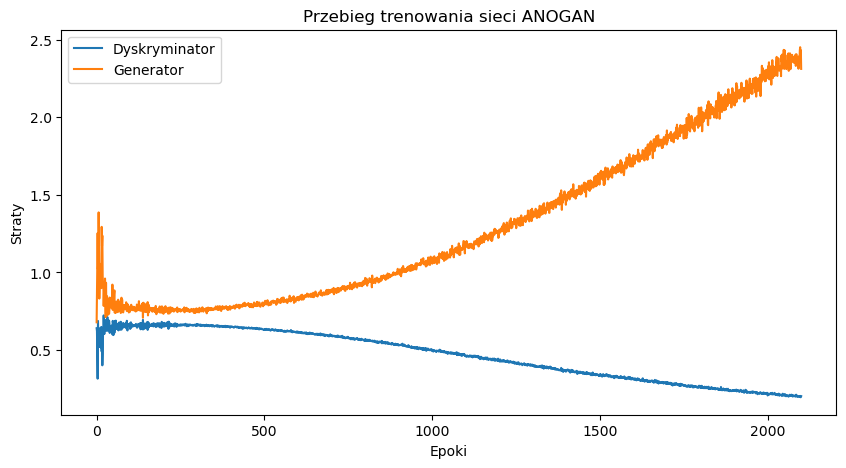

In [ ]:
# Komórka 14: Wykres strat
plt.figure(figsize=(10, 5))
plt.plot(losses_D, label='Dyskryminator')
plt.plot(losses_G, label='Generator')
plt.xlabel('Epoki')
plt.ylabel('Straty')
plt.legend()
plt.title('Przebieg trenowania sieci ANOGAN')
plt.show()

In [ ]:
def detect_anomaly(data, generator, discriminator):
    lambda_param = 0.1
    batch_size = data.size(0)
    anomaly_scores = []
    discriminator.eval()   # dyskryminator zawsze eval
    for i in range(batch_size):
        sample = data[i:i+1].to(device)
        generator.train()    # <-- KLUCZOWE!
        z = torch.randn(1, latent_dim, device=device, requires_grad=True)
        z_optimizer = optim.Adam([z], lr=0.01)
        for _ in range(100):
            z_optimizer.zero_grad()
            gen_sample = generator(z)
            loss = torch.nn.MSELoss()(gen_sample, sample)
            loss.backward()
            z_optimizer.step()
        generator.eval()     # <-- wracamy do eval na koniec dla bezpieczeństwa
        with torch.no_grad():
            gen_sample = generator(z)
            residual_loss = torch.nn.MSELoss()(gen_sample, sample)
            discriminator_score = discriminator(sample)
            anomaly_score = (1 - discriminator_score) + lambda_param * residual_loss
            anomaly_scores.append(anomaly_score.item())
        if (i+1) % 10 == 0 or i == 0:
            print(f"  Detekcja anomalii dla próbki {i+1}/{batch_size}, score: {anomaly_scores[-1]:.4f}")
    return np.array(anomaly_scores)

  Detekcja anomalii dla próbki 1/100, score: 0.6841
  Detekcja anomalii dla próbki 10/100, score: 0.1288
  Detekcja anomalii dla próbki 20/100, score: 0.0462
  Detekcja anomalii dla próbki 30/100, score: 0.0265
  Detekcja anomalii dla próbki 40/100, score: 0.0872
  Detekcja anomalii dla próbki 50/100, score: 0.4788
  Detekcja anomalii dla próbki 60/100, score: 0.2101
  Detekcja anomalii dla próbki 70/100, score: 0.1560
  Detekcja anomalii dla próbki 80/100, score: 0.0648
  Detekcja anomalii dla próbki 90/100, score: 0.2280
  Detekcja anomalii dla próbki 100/100, score: 0.0979
  Detekcja anomalii dla próbki 1/100, score: 0.9746
  Detekcja anomalii dla próbki 10/100, score: 0.1688
  Detekcja anomalii dla próbki 20/100, score: 0.3050
  Detekcja anomalii dla próbki 30/100, score: 0.2681
  Detekcja anomalii dla próbki 40/100, score: 1.0618
  Detekcja anomalii dla próbki 50/100, score: 0.7575
  Detekcja anomalii dla próbki 60/100, score: 1.0565
  Detekcja anomalii dla próbki 70/100, score: 0

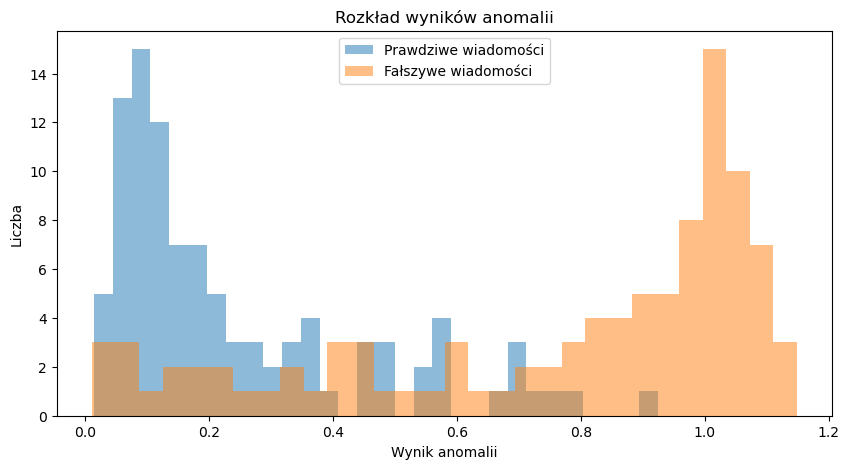

Przy użyciu progu 0.3972:
Fałszywy wskaźnik pozytywny (prawdziwe wiadomości wykryte jako fałszywe): 0.2000
Prawdziwy wskaźnik pozytywny (fałszywe wiadomości wykryte jako fałszywe): 0.8200
Gotowe!


In [ ]:
# Komórka 16: Testowanie detekcji anomalii i wykres
sample_size = min(100, real_embeds.size(0), fake_embeds.size(0))
real_scores = detect_anomaly(real_embeds[:sample_size], generator, discriminator)
fake_scores = detect_anomaly(fake_embeds[:sample_size], generator, discriminator)
plt.figure(figsize=(10, 5))
plt.hist(real_scores, bins=30, alpha=0.5, label='Prawdziwe wiadomości')
plt.hist(fake_scores, bins=30, alpha=0.5, label='Fałszywe wiadomości')
plt.xlabel('Wynik anomalii'); plt.ylabel('Liczba')
plt.legend(); plt.title('Rozkład wyników anomalii')
plt.show()
threshold = np.percentile(real_scores, 80) 
real_detected = (real_scores > threshold).mean()
fake_detected = (fake_scores > threshold).mean()
print(f"Przy użyciu progu {threshold:.4f}:")
print(f"Fałszywy wskaźnik pozytywny (prawdziwe wiadomości wykryte jako fałszywe): {real_detected:.4f}")
print(f"Prawdziwy wskaźnik pozytywny (fałszywe wiadomości wykryte jako fałszywe): {fake_detected:.4f}")
print("Gotowe!")

In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Tworzymy etykiety: 0 = real, 1 = fake
y_true = np.concatenate([np.zeros_like(real_scores), np.ones_like(fake_scores)])
# 2. Tworzymy predykcje na podstawie threshold
y_pred = np.concatenate([ (real_scores  > threshold).astype(int),
                          (fake_scores  > threshold).astype(int) ])


accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)


print(f"Threshold = {threshold:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Threshold = 0.3972
Accuracy : 0.8100
Precision: 0.8039
Recall   : 0.8200
F1-score : 0.8119


In [ ]:
# Komórka 17: Zapis modeli
# Zapisz modele i ich parametry
model_dir = './saved_models'
import os
os.makedirs(model_dir, exist_ok=True)

gen_path = os.path.join(model_dir, 'generator.pt')
disc_path = os.path.join(model_dir, 'discriminator.pt')
gen_state_path = os.path.join(model_dir, 'generator_state_dict.pt')
disc_state_path = os.path.join(model_dir, 'discriminator_state_dict.pt')

# Zapis całych modeli
torch.save(generator, gen_path)
torch.save(discriminator, disc_path)
# Zapis samych parametrów
torch.save(generator.state_dict(), gen_state_path)
torch.save(discriminator.state_dict(), disc_state_path)

print(f'Zapisano generator: {gen_path}')
print(f'Zapisano dyskryminator: {disc_path}')
print(f'Zapisano parametry generatora: {gen_state_path}')
print(f'Zapisano parametry dyskryminatora: {disc_state_path}')